# Kaggle House Prices - Advanced Regression Techniques

This notebook solves the Kaggle competition **"House Prices: Advanced Regression Techniques"**.

**Goal**
- Predict the sale price (`SalePrice`) of residential homes in Ames, Iowa.
- Use the provided training data to build a regression model.
- Generate predictions for the test set and create a submission file for Kaggle.

**Problem definition**
- **Input**: Tabular data describing each house (size, neighborhood, quality, etc.).
- **Target**: `SalePrice` (we will work with \(\log(1 + \text{SalePrice})\) as recommended by the competition to stabilize variance).
- **Metric**: Root Mean Squared Error (RMSE) on the log-transformed sale price.

**Requirements**
- Clear and reproducible data loading from the local `data/` folder.
- Well-structured pipeline for preprocessing, modeling, and evaluation.
- English comments and explanations for all key steps.

**High-level plan**
1. **Data loading & quick inspection**
   - Load `train.csv` and `test.csv` from the local `data/` directory.
   - Inspect shapes, basic statistics, and target distribution.
2. **Preprocessing & feature engineering**
   - Separate numerical and categorical features.
   - Handle missing values.
   - Apply appropriate scaling/encoding using a `ColumnTransformer` pipeline.
   - Log-transform the target variable `SalePrice`.
3. **Modeling**
   - Start with a baseline model (e.g., `RandomForestRegressor`).
   - Try a gradient-boosting model (`GradientBoostingRegressor` or `HistGradientBoostingRegressor`).
   - Use cross-validation on the training set to estimate performance.
4. **Model selection & training**
   - Compare models based on cross-validated RMSE (on log-transformed target).
   - Select the best-performing model.
   - Retrain the best model on the full training data.
5. **Prediction & submission**
   - Predict on the test set.
   - Convert log predictions back to original scale.
   - Create a Kaggle submission file `submission.csv`.

**Optimization plan**
- Start with simple, robust preprocessing (imputation + one-hot encoding).
- Use tree-based models that handle non-linearities and interactions well.
- Tune a few key hyperparameters using cross-validation (e.g., number of trees, learning rate, depth).
- If time allows, explore:
  - More advanced models (e.g., stacking/ensembles).
  - Extra feature engineering (e.g., total square footage, age of house, quality combinations).

In the following sections, we will implement this plan step by step.

In [15]:
# =============================
# 1. Imports and configuration
# =============================

import os
from pathlib import Path

import numpy as np  # numerical computations
import pandas as pd  # data loading and manipulation

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# XGBoost model (make sure xgboost is installed: `pip install xgboost`)
from xgboost import XGBRegressor

# Set display options for easier inspection
pd.set_option("display.max_columns", 100)

# Define paths relative to this notebook
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Train path exists:", TRAIN_PATH.exists())
print("Test path exists:", TEST_PATH.exists())


Base directory: d:\jupyter_notebook\experiments\Kaggle\House Prices
Data directory: d:\jupyter_notebook\experiments\Kaggle\House Prices\data
Train path exists: True
Test path exists: True


## 2. Load data and quick inspection

In this section we will:
- Load the training and test data from the local `data/` folder.
- Inspect the shape of each dataset.
- Take a brief look at the target variable `SalePrice`.

This quick inspection helps us verify that the files are correctly loaded and gives an initial sense of the data.

In [16]:
# =============================
# 2. Load data and basic info
# =============================

# Load training and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Show first few rows to understand the structure
train_df.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


SalePrice summary statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


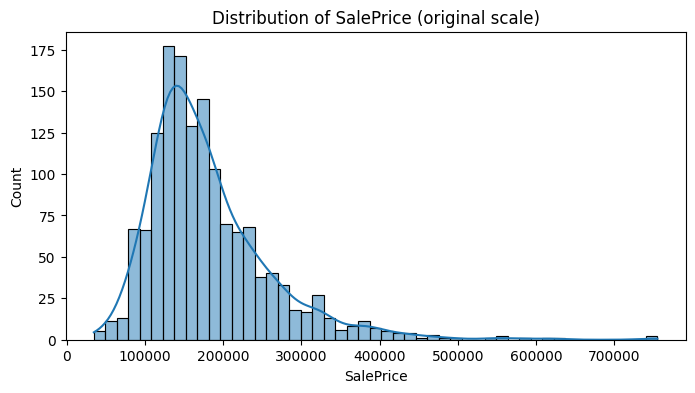

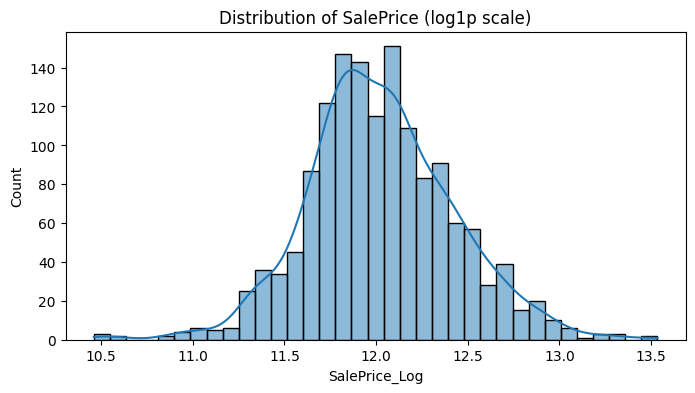

In [17]:
# Inspect basic statistics of the target variable SalePrice

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots show nicely in the notebook
%matplotlib inline

print("SalePrice summary statistics:")
print(train_df["SalePrice"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice (original scale)")
plt.show()

# Log-transform SalePrice to stabilize variance and make the distribution more Gaussian-like
train_df["SalePrice_Log"] = np.log1p(train_df["SalePrice"])

plt.figure(figsize=(8, 4))
sns.histplot(train_df["SalePrice_Log"], kde=True)
plt.title("Distribution of SalePrice (log1p scale)")
plt.show()

## 3. Preprocessing and feature engineering

We will now build a preprocessing pipeline that can be applied consistently to both the training and test data.

**Steps**:
- Separate features from the target variable.
- Identify numerical and categorical columns.
- For numerical features:
  - Impute missing values with the median.
  - Optionally scale features (some models benefit slightly from scaling, others are robust).
- For categorical features:
  - Impute missing values with the most frequent category.
  - Apply one-hot encoding, ignoring unknown categories in the test set.

We will wrap all these transformations inside a `ColumnTransformer` and `Pipeline` so that preprocessing and modeling can be combined cleanly.

In [18]:
# =============================
# 3. Preprocessing pipeline
# =============================

# Separate target and features
TARGET_COL = "SalePrice_Log"

# Drop target columns and identifier column "Id" from features
X = train_df.drop(["SalePrice", TARGET_COL, "Id"], axis=1)
y = train_df[TARGET_COL]

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}")

# Preprocessing for numerical data: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing for categorical data: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

preprocessor

Number of numerical features: 36
Number of categorical features: 43


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath...
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'MasVnrType', 'ExterQual',
                                  'ExterCond', 'Foundation', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Heating', 'HeatingQC',
                                  'CentralAir', 'Electrical', ...])])

## 4. Baseline models and cross-validation

In this section we will:
- Create two baseline regression models:
  - `RandomForestRegressor`
  - `GradientBoostingRegressor`
- Wrap each model together with the preprocessing pipeline into a single `Pipeline`.
- Evaluate each model using cross-validation on the training data.

We will report the **Root Mean Squared Error (RMSE)** on the **log-transformed** target (`SalePrice_Log`).
A lower RMSE indicates a better model.

In [ ]:
# =============================
# 4. Baseline models and CV
# =============================

RANDOM_STATE = 42

# Define models
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)

# Build full pipelines (preprocessing + model)
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model),
])

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gb_model),
])

# Helper function to compute cross-validated RMSE
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def rmse_cv(model_pipeline, X, y, cv):
    """Compute cross-validated RMSE for a given pipeline and data.

    We use `neg_mean_squared_error` as the scoring function and
    take the square root of the negative scores to get RMSE.
    """
    scores = cross_val_score(
        model_pipeline,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )
    rmse_scores = np.sqrt(-scores)
    return rmse_scores


# Evaluate Random Forest
rf_rmse_scores = rmse_cv(rf_pipeline, X, y, cv)
print("RandomForestRegressor CV RMSE (log SalePrice):")
print("  Scores:", rf_rmse_scores)
print("  Mean RMSE:", rf_rmse_scores.mean())
print("  Std RMSE:", rf_rmse_scores.std())

# Evaluate Gradient Boosting
gb_rmse_scores = rmse_cv(gb_pipeline, X, y, cv)
print("\nGradientBoostingRegressor CV RMSE (log SalePrice):")
print("  Scores:", gb_rmse_scores)
print("  Mean RMSE:", gb_rmse_scores.mean())
print("  Std RMSE:", gb_rmse_scores.std())

## 5. Simple hyperparameter tuning

Based on the baseline results, we will perform a **small manual hyperparameter search**.

For simplicity and clarity (rather than exhaustiveness), we will:
- Fix the preprocessing pipeline.
- Try a few reasonable configurations for `GradientBoostingRegressor`.
- Compare their cross-validated RMSE and pick the best one.

This gives an initial sense of how sensitive the model is to hyperparameters without running a large grid search.

In [ ]:
# =============================
# 5. Simple hyperparameter search (Gradient Boosting)
# =============================

# To keep the search fast on a local machine, we:
# - Use fewer parameter combinations.
# - Use 3-fold cross-validation instead of 5-fold.

from sklearn.model_selection import KFold

param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3},
]

# A lighter CV configuration for hyperparameter search
cv_search = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results = []

for params in param_grid:
    print("Evaluating params:", params)
    model = GradientBoostingRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=RANDOM_STATE,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scores = rmse_cv(pipeline, X, y, cv_search)
    mean_rmse = scores.mean()
    std_rmse = scores.std()

    results.append({
        "params": params,
        "mean_rmse": mean_rmse,
        "std_rmse": std_rmse,
    })

    print(f"  Mean RMSE: {mean_rmse:.5f} (std: {std_rmse:.5f})\n")

# Convert results to a DataFrame for easier comparison
results_df = pd.DataFrame(results).sort_values("mean_rmse")
print("\nHyperparameter search results (sorted by mean RMSE):")
results_df

## 6. Train final model and generate predictions (with XGBoost)

In this section we will switch to an **XGBoost** model for the final training and prediction.

Once we have chosen a good set of hyperparameters (for example, from the XGBoost tuning section), we will:
- Refit the XGBoost model using **all** available training data.
- Apply the same preprocessing to the test set.
- Predict the log-transformed sale prices.
- Convert predictions back to the original `SalePrice` scale using the inverse of `log1p`.
- Create a submission file in the required Kaggle format.

The Kaggle submission format requires two columns:
- `Id`: the house identifier from the test set.
- `SalePrice`: the predicted sale price on the original scale.

## 7. XGBoost model and systematic hyperparameter tuning

In this section we will:
- Build an XGBoost-based regression pipeline (`preprocessor` + `XGBRegressor`).
- Define a **small but systematic** hyperparameter search space.
- Evaluate each configuration using cross-validated RMSE on the log-transformed target.
- Summarize the results in a DataFrame for easy comparison.

### Tuning strategy

To keep the search computationally reasonable on a local machine, we:
- Use 3-fold cross-validation for tuning.
- Limit the search to a small grid over the most important XGBoost hyperparameters:
  - `n_estimators`: number of boosting rounds.
  - `learning_rate` (eta): step size shrinkage.
  - `max_depth`: depth of individual trees.
  - `subsample`: row subsampling ratio.
  - `colsample_bytree`: column subsampling ratio.

You can start with this grid, inspect the best region, and then refine the grid around the best configuration.

In [19]:
# =============================
# 7. XGBoost model and hyperparameter tuning
# =============================

from sklearn.model_selection import ParameterGrid

# Define a base set of XGBoost parameters
xgb_base_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",  # efficient on CPU
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Define a small, systematic hyperparameter grid
xgb_param_grid = {
    "n_estimators": [300, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_results = []

# Use a lighter CV setup for tuning
xgb_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for params in ParameterGrid(xgb_param_grid):
    # Merge base params with the grid params
    all_params = {**xgb_base_params, **params}
    print("Evaluating XGBoost params:", all_params)

    xgb_model = XGBRegressor(**all_params)

    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ])

    scores = rmse_cv(xgb_pipeline, X, y, xgb_cv)
    mean_rmse = scores.mean()
    std_rmse = scores.std()

    xgb_results.append({
        "params": all_params,
        "mean_rmse": mean_rmse,
        "std_rmse": std_rmse,
    })

    print(f"  Mean RMSE: {mean_rmse:.5f} (std: {std_rmse:.5f})\n")

# Collect results in a DataFrame for inspection
xgb_results_df = pd.DataFrame(xgb_results).sort_values("mean_rmse")
print("\nXGBoost hyperparameter search results (sorted by mean RMSE):")
xgb_results_df.head(10)

Evaluating XGBoost params: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
  Mean RMSE: 0.13454 (std: 0.01462)

Evaluating XGBoost params: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
  Mean RMSE: 0.13690 (std: 0.01605)

Evaluating XGBoost params: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
  Mean RMSE: 0.13297 (std: 0.01449)

Evaluating XGBoost params: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}
  Mea

,params,mean_rmse,std_rmse
26,"{'objective': 'reg:squarederror', 'tree_method...",0.131844,0.016981
24,"{'objective': 'reg:squarederror', 'tree_method...",0.132650,0.016275
10,"{'objective': 'reg:squarederror', 'tree_method...",0.132889,0.016631
2,"{'objective': 'reg:squarederror', 'tree_method...",0.132972,0.014488
6,"{'objective': 'reg:squarederror', 'tree_method...",0.133036,0.016021
22,"{'objective': 'reg:squarederror', 'tree_method...",0.133109,0.016082
14,"{'objective': 'reg:squarederror', 'tree_method...",0.133353,0.015069
18,"{'objective': 'reg:squarederror', 'tree_method...",0.133360,0.015863
15,"{'objective': 'reg:squarederror', 'tree_method...",0.133823,0.015934
8,"{'objective': 'reg:squarederror', 'tree_method...",0.133864,0.016360


In [20]:
# =============================
# 6. Train final model and generate submission (XGBoost)
# =============================

# Here we pick a good XGBoost configuration (you can adjust these
# hyperparameters based on the XGBoost tuning results).

best_xgb_params = {
    "n_estimators": 400,
    "learning_rate": 0.03,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

final_model = XGBRegressor(
    n_estimators=best_xgb_params["n_estimators"],
    learning_rate=best_xgb_params["learning_rate"],
    max_depth=best_xgb_params["max_depth"],
    subsample=best_xgb_params["subsample"],
    colsample_bytree=best_xgb_params["colsample_bytree"],
    objective="reg:squarederror",
    tree_method="hist",  # fast histogram-based algorithm
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model),
])

# Fit the final pipeline on all training data
final_pipeline.fit(X, y)

# Prepare test features (drop Id to match training features)
X_test = test_df.drop(["Id"], axis=1)

# Predict log-transformed SalePrice on the test set
log_preds_test = final_pipeline.predict(X_test)

# Convert back to original SalePrice scale
saleprice_preds = np.expm1(log_preds_test)

# Build submission DataFrame
submission_df = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": saleprice_preds,
})

# Save to CSV in the current working directory
submission_path = BASE_DIR / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print("Submission file saved to:", submission_path)
submission_df.head()

Submission file saved to: d:\jupyter_notebook\experiments\Kaggle\House Prices\submission.csv


,Id,SalePrice
0,1461,123796.007812
1,1462,151838.625000
2,1463,183791.546875
3,1464,185458.421875
4,1465,193345.703125
